In [36]:
from cd.algs.cheb import Cheb
from simulation.gen_pend import *
from cd.algs.cd_poly import CDPolynomial

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [37]:
param_dists = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.norm(loc=0, scale=1),
    'b': stats.uniform(loc=0, scale=0.01)
}

times, trajs = gen_trajs(10_000, 3., 128, param_dists)
trajs.shape

(10000, 2, 128)

In [38]:
def to_sincos(trajs):
    sincos = np.concatenate((np.sin(trajs[:, :1]),
                             np.cos(trajs[:, :1])),
                             axis=1)
    return np.concatenate((sincos, trajs[:, 1:]), axis=1)

trajs = to_sincos(trajs)

In [39]:
trajs.shape

(10000, 3, 128)

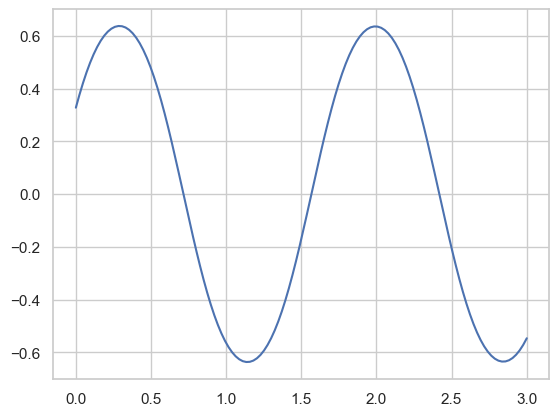

In [40]:
plt.plot(times, trajs[0, 0])

In [41]:
cheb = Cheb(10, interval=[0., 3.])
coeffs, closest_idx = cheb.get_coeffs(trajs[:, 0], times, get_idx=True)

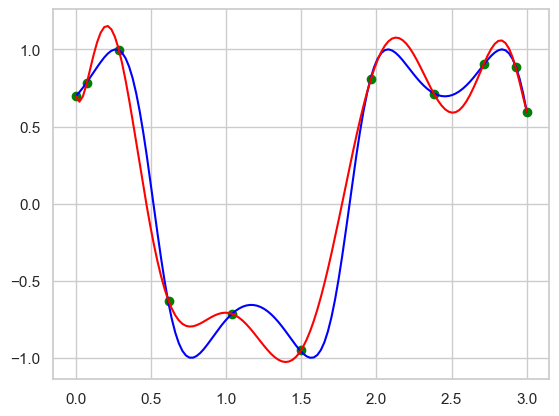

In [42]:
from numpy.polynomial.chebyshev import chebvander, chebval

i = np.random.randint(0, 1000)
plt.plot(times, trajs[i, 0], color='blue')
plt.plot(times, cheb.eval(times, coeffs[i]), color='red')

plt.scatter(cheb.nodes, trajs[i, 0, closest_idx], color='green')

In [28]:
p = CDPolynomial(coeffs, degree=3)

In [19]:
coeffs.shape

(10000, 11)

In [20]:
print(f'Fraction of in-distribution samples classified as ood: {(p(coeffs) > p.mean).mean()}')

Fraction of in-distribution samples classified as ood: 0.1864


In [21]:
p(coeffs).min(), p(coeffs).max()

(np.float64(14.280818866742619), np.float64(9999.362423938177))

In [22]:
param_dists_ood = param_dists.copy()
param_dists_ood['b'] = stats.uniform(1., 0.)
_, trajs_ood = gen_trajs(1000, 3., 128, param_dists_ood)
trajs_ood = to_sincos(trajs_ood)
trajs_ood.shape

(1000, 3, 128)

In [24]:
coeffs_ood = cheb.get_coeffs(trajs_ood[:, 0], times)

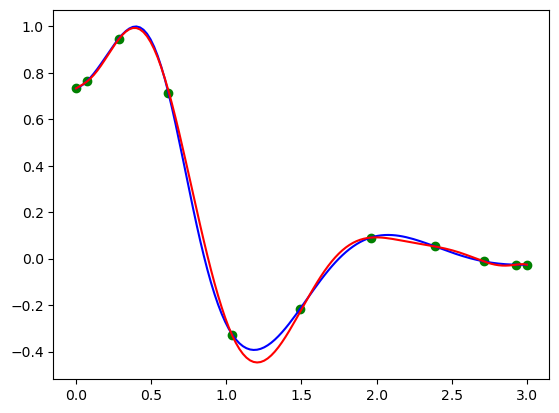

In [ ]:
i = np.random.randint(0, 1000)
plt.plot(times, trajs_ood[i, 0], color='blue')

times_mapped = (2 * times - 3) / 3
plt.plot(times, chebval(times_mapped, coeffs_ood[i]), color='red')

#plt.plot(times, chebval(times, coeffs), color='green')

plt.scatter(times[closest_idx], trajs_ood[i, 0, closest_idx], color='green')

In [29]:
p(coeffs).max(), p(coeffs_ood).min()

(np.float64(9999.362423938177), np.float64(462.7061687116884))

In [30]:
(p(coeffs_ood) > p.mean).mean()

np.float64(1.0)

In [31]:
degree = 12
time = 3.

bs = np.linspace(0., .3, 11)
ls = np.linspace(.9, 1.1, 11)

data = []

param_dists = {
    'q': stats.uniform(-np.pi, 2 * np.pi),
    'v': stats.norm(loc=0, scale=1),
    'b': stats.uniform(loc=0, scale=0.1)
    }

times, trajs = gen_trajs(1_000, time, 128, param_dists)
trajs = to_sincos(trajs)

coeffs = cheb.get_coeffs(trajs[:, 0], times)
p = CDPolynomial(coeffs, degree=3)

for b_idx, b in enumerate(bs):
    for l_idx, l in enumerate(ls):
        param_dists_ood = param_dists.copy()
        param_dists_ood['b'] = stats.uniform(b, 0.)
        _, trajs_ood = gen_trajs(1000, time, 128, param_dists_ood, length=l)
        trajs_ood = to_sincos(trajs_ood)

        coeffs_ood = cheb.get_coeffs(trajs_ood[:, 0], times)

        acc = (p(coeffs_ood) > p.mean).mean()
        data.append({'b': b, 'l': l, 'acc': acc})
    print(f'Done with b = {b}.')

df = pd.DataFrame(data)

Done with b = 0.0.
Done with b = 0.03.
Done with b = 0.06.
Done with b = 0.09.
Done with b = 0.12.
Done with b = 0.15.
Done with b = 0.18.
Done with b = 0.21.
Done with b = 0.24.
Done with b = 0.27.
Done with b = 0.3.


In [13]:
#df.to_csv('./data/cheb_acc.csv')
df = pd.read_csv('data/cheb_acc.csv')

In [15]:
df

,Unnamed: 0,b,l,acc
0,0,0.0,0.90,0.999
1,1,0.0,0.92,0.998
2,2,0.0,0.94,0.994
3,3,0.0,0.96,0.991
4,4,0.0,0.98,0.970
...,...,...,...,...
116,116,0.3,1.02,0.999
117,117,0.3,1.04,1.000
118,118,0.3,1.06,0.998
119,119,0.3,1.08,1.000


Text(0, 0.5, 'accuracy')

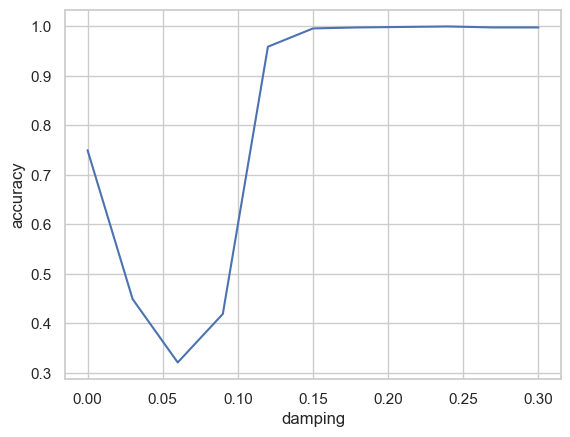

In [20]:
sns.lineplot(df[df['l'] == 1.0], x='b', y='acc')
plt.xlabel('damping')
plt.ylabel('accuracy')

Text(0.5, 1.0, 'Accuracy for different lengths')

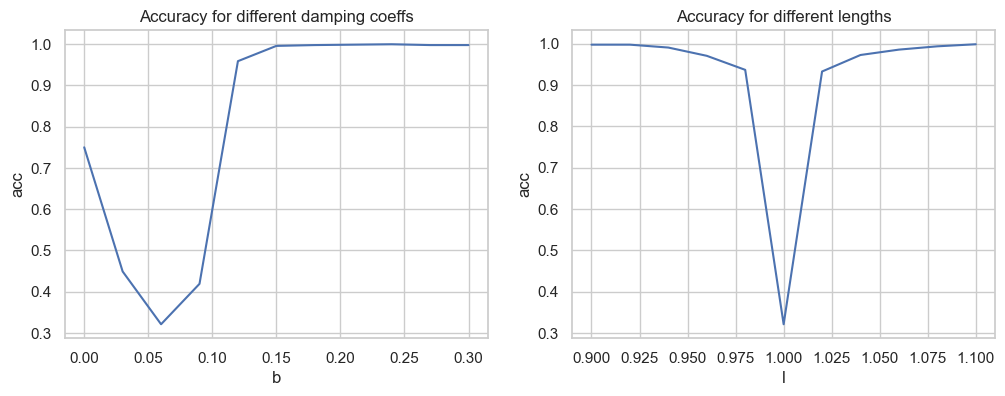

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.set_theme(style="whitegrid")

sns.lineplot(df[df['l'] == 1.0], x='b', y='acc', ax=ax[0])
ax[0].set_title('Accuracy for different damping coeffs')

sns.lineplot(df[df['b'] == .06], x='l', y='acc', ax=ax[1])
ax[1].set_title('Accuracy for different lengths')

Text(0.5, 0.92, 'Accuracy surface for Cheb')

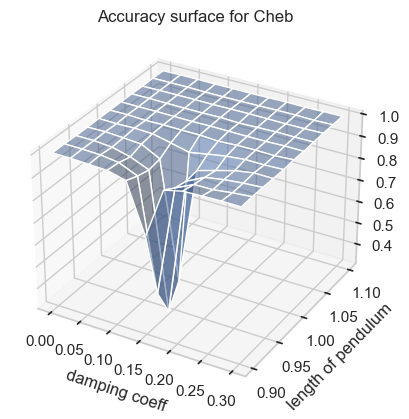

In [37]:
X, Y = np.meshgrid(bs, ls)
Z = df.iloc[:, -1].to_numpy().reshape(11, 11)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=.5)
ax.set_xlabel('damping coeff')
ax.set_ylabel('length of pendulum')
ax.set_title('Accuracy surface for Cheb')